# Pipeline Evaluation
Reads `outputs/privacy/` and `outputs/medical/`. No pipeline code here.

In [1]:
import json, glob
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

privacy = [json.loads(f.read_text()) for f in sorted(Path('../outputs/privacy').glob('*_privacy.json'))]
medical = [json.loads(f.read_text()) for f in sorted(Path('../outputs/medical').glob('*_medical.json'))]
print(f'{len(privacy)} privacy records, {len(medical)} medical records')

12 privacy records, 12 medical records


,note_id,pii_count,pii_labels,model
0,note_001_copd,7,"date_of_birth, email, first_name, medical_reco...",OpenMed/OpenMed-PII-GTEMed-Base-149M-v1
1,note_002_ra,9,"age, date_of_birth, email, first_name, last_na...",OpenMed/OpenMed-PII-GTEMed-Base-149M-v1
2,note_003_ami,13,"age, date, date_of_birth, email, first_name, l...",OpenMed/OpenMed-PII-GTEMed-Base-149M-v1
3,note_004_diabetes,18,"age, date, date_of_birth, email, first_name, l...",OpenMed/OpenMed-PII-GTEMed-Base-149M-v1
4,note_005_oncology,12,"age, blood_type, date, date_of_birth, email, f...",OpenMed/OpenMed-PII-GTEMed-Base-149M-v1
5,note_006_stroke,12,"age, date_of_birth, email, first_name, last_na...",OpenMed/OpenMed-PII-GTEMed-Base-149M-v1
6,note_007_sepsis,16,"age, date, date_of_birth, email, first_name, l...",OpenMed/OpenMed-PII-GTEMed-Base-149M-v1
7,note_008_depression,10,"age, date, date_of_birth, email, first_name, l...",OpenMed/OpenMed-PII-GTEMed-Base-149M-v1
8,note_009_ckd,15,"age, date, date_of_birth, email, first_name, l...",OpenMed/OpenMed-PII-GTEMed-Base-149M-v1
9,note_010_asthma_paeds,17,"age, date, email, first_name, last_name, medic...",OpenMed/OpenMed-PII-GTEMed-Base-149M-v1


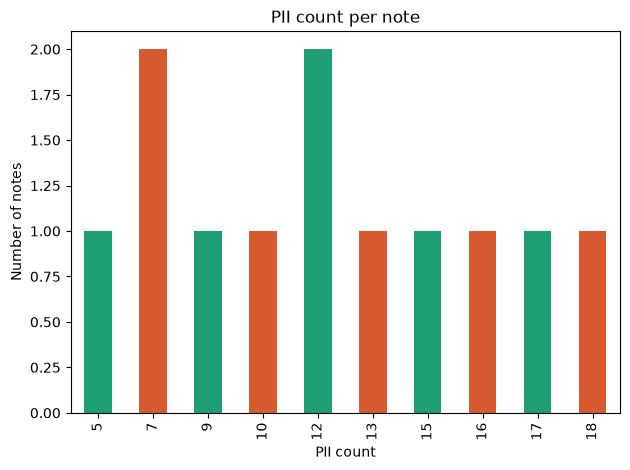

In [2]:
# Gate results
gate_df = pd.DataFrame([{
    'note_id': r['note_id'],
    'pii_count': len(r.get('pii_entities', [])),
    'pii_labels': ', '.join(sorted({e.get('label', '') for e in r.get('pii_entities', [])})),
    'model': r.get('model'),
} for r in privacy])
display(gate_df)
gate_df['pii_count'].value_counts().sort_index().plot.bar(
    color=['#1D9E75','#D85A30'], title='PII count per note')
plt.xlabel('PII count')
plt.ylabel('Number of notes')
plt.tight_layout(); plt.show()

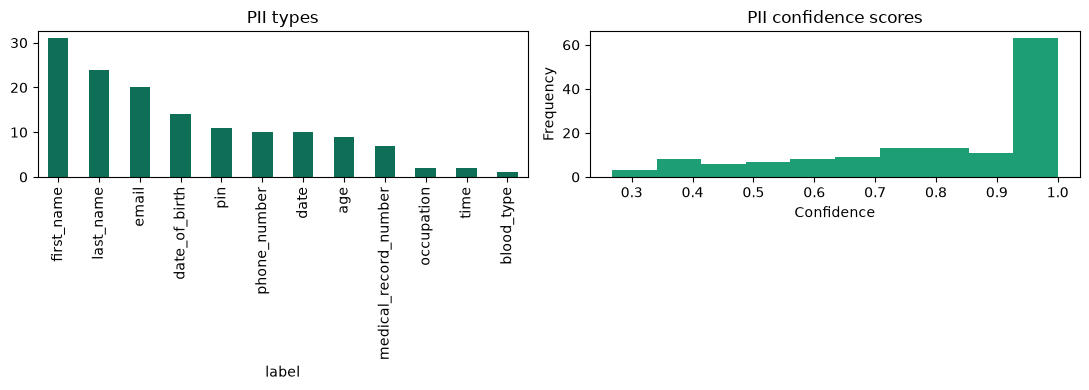

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

pii_df["label"].value_counts().plot.bar(
    ax=axes[0],
    color="#0F6E56",
    title="PII types"
)

pii_df["score"].plot.hist(
    ax=axes[1],
    bins=10,
    color="#1D9E75",
    title="PII confidence scores"
)

axes[1].set_xlabel("Confidence")
plt.tight_layout()
plt.show()

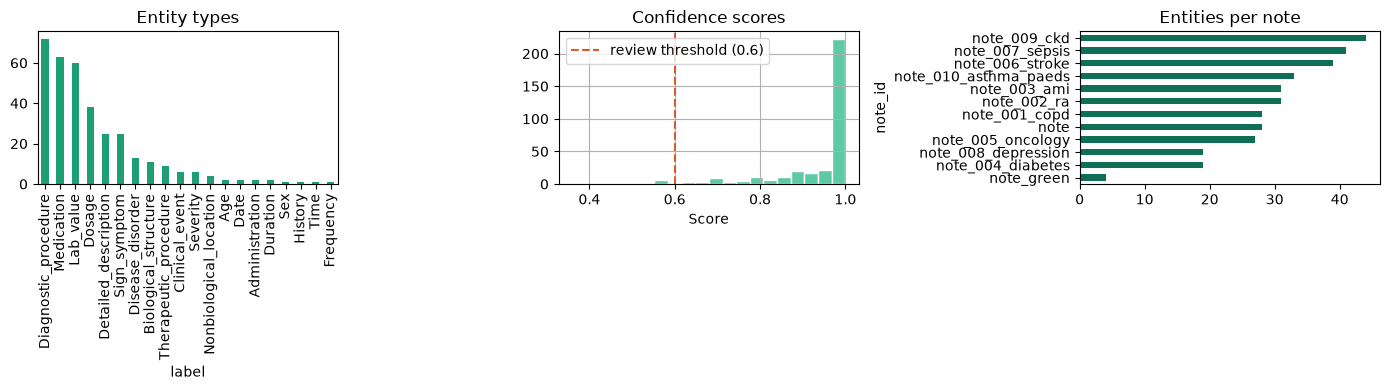

In [5]:
# Clinical entity distribution and confidence scores
ent_rows = [
    {"note_id": r["note_id"], **e}
    for r in medical
    for e in r.get("entities", [])
]

ent_df = pd.DataFrame(ent_rows)

if ent_df.empty:
    print("No medical entities found.")
else:
    review_threshold = 0.60

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    ent_df["label"].value_counts().plot.bar(
        ax=axes[0],
        color="#1D9E75",
        title="Entity types"
    )

    ent_df["score"].hist(
        ax=axes[1],
        bins=20,
        color="#5DCAA5",
        edgecolor="white"
    )
    axes[1].axvline(
        review_threshold,
        color="#D85A30",
        linestyle="--",
        label=f"review threshold ({review_threshold})"
    )
    axes[1].set_title("Confidence scores")
    axes[1].set_xlabel("Score")
    axes[1].legend()

    ent_df.groupby("note_id")["label"].count().sort_values().plot.barh(
        ax=axes[2],
        color="#0F6E56",
        title="Entities per note"
    )

    plt.tight_layout()
    plt.show()

In [6]:
# Entities that would be filtered in production (score < 0.80)
review = ent_df[ent_df['score'] < 0.80][['note_id','text','label','score']].sort_values('score')
print(f'{len(review)} entities below production threshold:')
display(review.head(20))

43 entities below production threshold:


,note_id,text,label,score
238,note_009_ckd,d,Sign_symptom,0.360
210,note_007_sepsis,2l,Dosage,0.392
40,note_002_ra,2,Lab_value,0.488
289,note_010_asthma_paeds,every,Frequency,0.492
149,note_006_stroke,d,Diagnostic_procedure,0.557
184,note_007_sepsis,ina,Biological_structure,0.559
50,note_002_ra,38,Lab_value,0.561
69,note_003_ami,tr,Diagnostic_procedure,0.571
4,note_001_copd,rba,Detailed_description,0.582
320,note,rba,Detailed_description,0.582
